# Error Analysis

This notebook generates detailed error logs.

**Models Evaluated:**
1. **Qwen 2.5 7B Instruct**
2. **Qwen 2.5 7B Coder**
3. **Gemini 3.0 Pro**

In [ ]:
#  Stratified Sampling for Manual Error Analysis ---
import random
import json
import pandas as pd
import os
import re

def sample_errors_stratified(model_name, error_file_path, samples_per_complexity=2):
    print(f"\nSampling errors for {model_name}...")
    try:
        with open(error_file_path, 'r', encoding='utf-8') as f:
            errors = json.load(f)
    except FileNotFoundError:
        print(f"Error file not found: {error_file_path}")
        return {}

    # Group by complexity
    grouped_errors = {}
    for key, item in errors.items():
        # Get complexity (num_cities)
        num_cities = int(item.get('num_cities', 0))
        if num_cities == 0 and 'cities' in item:
             # Fallback if num_cities missing
             try:
                 num_cities = len(item['cities'].split('**'))
             except:
                 continue
        
        if num_cities not in grouped_errors:
            grouped_errors[num_cities] = []
        grouped_errors[num_cities].append((key, item))
    
    # Sample
    sampled_data = {}
    total_sampled = 0
    
    # We want complexities 3 to 10
    sorted_complexities = sorted([c for c in grouped_errors.keys() if 3 <= c <= 10])
    
    for complexity in sorted_complexities:
        items = grouped_errors[complexity]
        count = len(items)
        
        # Take min(samples_per_complexity, count)
        n_to_sample = min(samples_per_complexity, count)
        selected = random.sample(items, n_to_sample)
        
        print(f"  Complexity {complexity}: Found {count} errors, sampled {n_to_sample}")
        
        for key, item_data in selected:
            sampled_data[key] = item_data
            total_sampled += 1

    output_filename = f"{os.path.dirname(error_file_path)}/{model_name.replace(' ', '_')}_sampled_errors.json"
    
    # Custom Compact Formatting
    json_str = json.dumps(sampled_data, indent=4)
    # Compact inner lists: [ "City", 123 ] -> ["City", 123]
    # This regex looks for: [ \n
    #  (spaces) "String" , \n
    #  (spaces) Digits \n
    #  (spaces) ]
    json_str = re.sub(r'\[\s+"(.*?)",\s+(\d+)\s+\]', r'["\1", \2]', json_str)
    
    # Write the formatted string
    with open(output_filename, 'w', encoding='utf-8') as f:
        f.write(json_str)
    
    print(f"Saved {total_sampled} sampled errors to {output_filename}")
    return sampled_data

# Run Sampling
# 1. Qwen 7B Instruct
sample_errors_stratified(
    "Qwen 2.5 7B Instruct", 
    "data/qwen2.5-7b/trip_planning_errors_qwen2.5-7b.json", 
    samples_per_complexity=2
)

# 2. Qwen 7B Coder
sample_errors_stratified(
    "Qwen 2.5 7B Coder", 
    "data/qwen2.5-7b-coder/trip_planning_errors_qwen2.5-7b-coder.json", 
    samples_per_complexity=2
)



Sampling errors for Qwen 2.5 7B Instruct...
  Complexity 3: Found 17 errors, sampled 2
  Complexity 4: Found 20 errors, sampled 2
  Complexity 5: Found 19 errors, sampled 2
  Complexity 6: Found 20 errors, sampled 2
  Complexity 7: Found 20 errors, sampled 2
  Complexity 8: Found 20 errors, sampled 2
  Complexity 9: Found 20 errors, sampled 2
  Complexity 10: Found 20 errors, sampled 2
Saved 16 sampled errors to data/qwen2.5-7b/Qwen_2.5_7B_Instruct_sampled_errors.json

Sampling errors for Qwen 2.5 7B Coder...
  Complexity 3: Found 17 errors, sampled 2
  Complexity 4: Found 17 errors, sampled 2
  Complexity 5: Found 18 errors, sampled 2
  Complexity 6: Found 20 errors, sampled 2
  Complexity 7: Found 20 errors, sampled 2
  Complexity 8: Found 20 errors, sampled 2
  Complexity 9: Found 20 errors, sampled 2
  Complexity 10: Found 20 errors, sampled 2
Saved 16 sampled errors to data/qwen2.5-7b-coder/Qwen_2.5_7B_Coder_sampled_errors.json


{'trip_planning_example_96': {'num_cities': '3',
  'cities': 'Naples**Berlin**Krakow',
  'durations': '6**7**4',
  'prompt_0shot': 'You plan to visit 3 European cities for 15 days in total. You only take direct flights to commute between cities. You plan to stay in Berlin for 7 days. You plan to stay in Naples for 6 days. You plan to stay in Krakow for 4 days. You would like to meet your friends at Krakow between day 12 and day 15 to tour together.\n\nHere are the cities that have direct flights:\nBerlin and Krakow, Naples and Berlin.\n\nFind a trip plan of visiting the cities for 15 days by taking direct flights to commute between them.',
  'prompt_5shot': 'You are an expert at planning trips. You are given a few constraints regarding the cities to visit and the durations of staying at each city. You are also given the flight information between the cities. Here are a few example tasks and solutions:\n\nTASK: You plan to visit 3 European cities for 7 days in total. You only take direc

## Error Category Analysis

We analyze the distribution of error types across the three models. 

**Sample Sizes:**
- **Gemini 3.0 Pro:** 17 errors (Total errors found in dataset)
- **Qwen 2.5 7B Instruct:** 16 errors await (Stratified sample from 156 total errors)
- **Qwen 2.5 7B Coder:** 16 errors (Stratified sample from 152 total errors)

**Error Categories:**
- **Semantic Error - Constraint Violation**: Failed to meet duration, city presence, or ordering constraints.
- **Semantic Error - Invalid Path**: Flight does not exist between cities.
- **Semantic Error - Omission**: Missed a city required by the prompt.
- **Syntax Error**: Malformed output (e.g., Markdown issues, missing plan section).

Parsing Error Files...


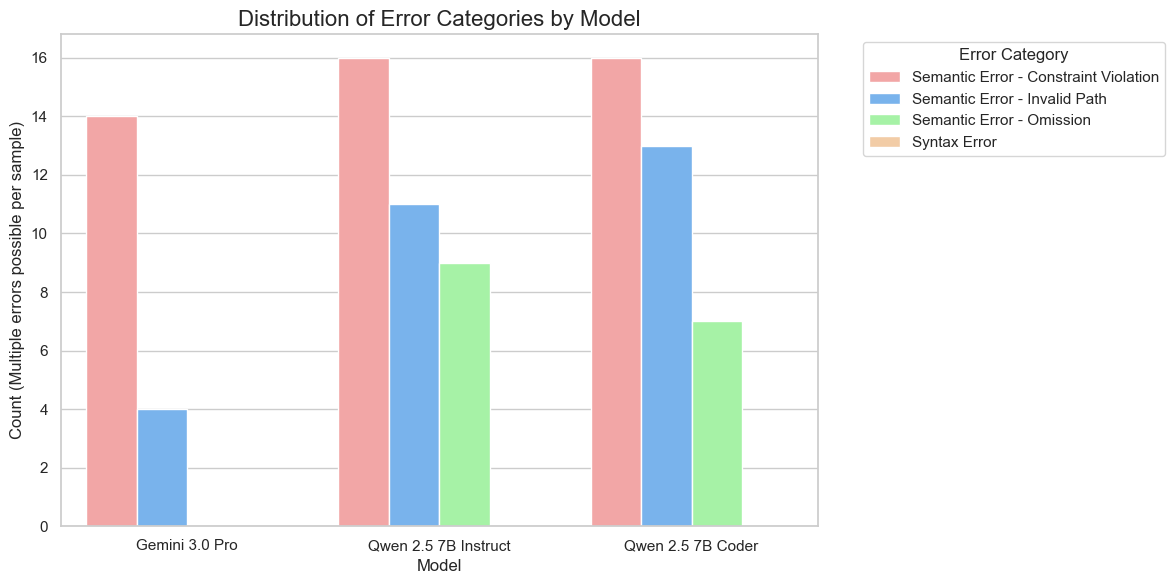

### Summary Counts

Model,Gemini 3.0 Pro,Qwen 2.5 7B Coder,Qwen 2.5 7B Instruct
Error Category,,,
Semantic Error - Constraint Violation,14,16,16
Semantic Error - Invalid Path,4,13,11
Semantic Error - Omission,0,7,9
Syntax Error,0,0,0


In [16]:
# --- 5. Generate Error Summary & Visualization ---
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# File paths
files = {
    "Gemini 3.0 Pro": "data/gemini3-pro/trip_planning_errors_gemini3-pro.json",
    "Qwen 2.5 7B Instruct": "data/qwen2.5-7b/Qwen_2.5_7B_Instruct_sampled_errors.json",
    "Qwen 2.5 7B Coder": "data/qwen2.5-7b-coder/Qwen_2.5_7B_Coder_sampled_errors.json"
}

# Categories & Colors
categories = [
    "Semantic Error - Constraint Violation",
    "Semantic Error - Invalid Path",
    "Semantic Error - Omission",
    "Syntax Error"
]
color_map = {
    "Semantic Error - Constraint Violation": "#ff9999",  # Red/Pink
    "Semantic Error - Invalid Path": "#66b3ff",        # Blue
    "Semantic Error - Omission": "#99ff99",          # Green
    "Syntax Error": "#ffcc99"                        # Orange
}

results = []

print("Parsing Error Files...")
for model_name, file_path in files.items():
    if not os.path.exists(file_path):
        print(f"Warning: File not found for {model_name}: {file_path}")
        continue

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"Error reading {model_name}: {e}")
        continue

    # Standardize Item List
    items = []
    if isinstance(data, dict):
        # Check if values are the items (Gemini format often dict of dicts)
        # Also handle Qwen sampled structure which might be {"key": {data}}
        for k, v in data.items():
            if isinstance(v, dict):
                items.append(v)
            else:
                # Should likely be dict, but defensive coding
                pass 
    elif isinstance(data, list):
        items = data

    total_count = len(items)
    
    # Count Errors
    counts = {cat: 0 for cat in categories}
    for item in items:
        # Handle both list and string formats for error_categories
        cats = item.get("error_categories", [])
        if isinstance(cats, str):
            cats = [cats]
        
        for c in cats:
            for known_cat in categories:
                if known_cat in c:
                    counts[known_cat] += 1
    
    # Store Results for DataFrame
    for cat, count in counts.items():
        results.append({
            "Model": model_name,
            "Error Category": cat,
            "Count": count,
            "Percentage": (count / total_count * 100) if total_count > 0 else 0
        })

# Create DataFrame
df = pd.DataFrame(results)

# --- Plotting ---
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Pivot for stacked bar chart consistency or use grouped bar chart
# Grouped bar chart is better for comparing categories side-by-side
ax = sns.barplot(
    data=df, 
    x="Model", 
    y="Count", 
    hue="Error Category", 
    palette=color_map
)

plt.title("Distribution of Error Categories by Model", fontsize=16)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Count (Multiple errors possible per sample)", fontsize=12)
plt.legend(title="Error Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display Summary Table
pivot_df = df.pivot(index="Error Category", columns="Model", values="Count").fillna(0).astype(int)
display(Markdown("### Summary Counts"))
display(pivot_df)
